In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../results/dvs128_snn_01_to_09_batch8_3seeds_maxmem_beta05.txt")
df.head()

,representation,coding,train_size,val_size,seed,batch_size,val_rate_acc,val_temp_acc,test_rate_acc,test_temp_acc,epoch,batch_size.1,loss,beta
0,n_bins,max_mem,0.1,0.1,42.0,8.0,0.0,0.0,0.5265,0.5341,17.0,8.0,max_mem,0.5
1,n_bins,max_mem,0.3,0.1,42.0,8.0,0.0,0.0,0.6553,0.6023,23.0,8.0,max_mem,0.5
2,n_bins,max_mem,0.5,0.1,42.0,8.0,0.0,0.0,0.7992,0.7424,21.0,8.0,max_mem,0.5
3,n_bins,max_mem,0.7,0.1,42.0,8.0,0.0,0.0,0.8144,0.7311,19.0,8.0,max_mem,0.5
4,n_bins,max_mem,0.9,0.1,42.0,8.0,0.0,0.0,0.8333,0.7992,19.0,8.0,max_mem,0.5


In [4]:
df = df.drop(['val_rate_acc', 'val_temp_acc', 'batch_size.1', 'coding'], axis=1)
df['epoch'] = df['epoch'] + 1
df.head()

,representation,train_size,val_size,seed,batch_size,test_rate_acc,test_temp_acc,epoch,loss,beta
0,n_bins,0.1,0.1,42.0,8.0,0.5265,0.5341,18.0,max_mem,0.5
1,n_bins,0.3,0.1,42.0,8.0,0.6553,0.6023,24.0,max_mem,0.5
2,n_bins,0.5,0.1,42.0,8.0,0.7992,0.7424,22.0,max_mem,0.5
3,n_bins,0.7,0.1,42.0,8.0,0.8144,0.7311,20.0,max_mem,0.5
4,n_bins,0.9,0.1,42.0,8.0,0.8333,0.7992,20.0,max_mem,0.5


In [5]:
grouped_data = df.groupby(['train_size', 'representation']).agg({
    'test_rate_acc': 'mean',
    'test_temp_acc': 'mean',
    'epoch': 'mean'
}).reset_index()
grouped_data.head()

,train_size,representation,test_rate_acc,test_temp_acc,epoch
0,0.1,binary,0.176767,0.178033,20.0
1,0.1,n_bins,0.558100,0.558100,20.0
2,0.1,spike_count,0.468433,0.428033,20.0
3,0.1,time_window,0.441900,0.399000,20.0
4,0.1,timesurface,0.174233,0.162900,20.0


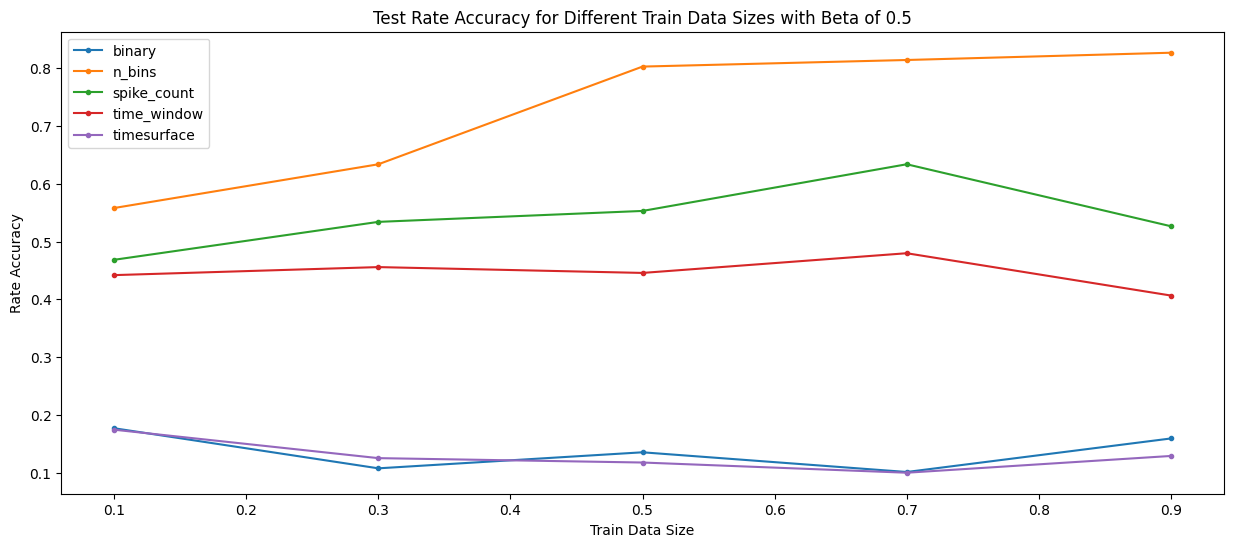

In [6]:
sns.reset_orig()

fig, ax = plt.subplots(figsize=(15, 6))

for representation in grouped_data['representation'].unique():
    rep_data = grouped_data[grouped_data['representation'] == representation]
    plt.plot(rep_data['train_size'], rep_data['test_rate_acc'], label=f'{representation}', marker='.')

plt.xlabel('Train Data Size')
plt.ylabel('Rate Accuracy')
plt.title('Test Rate Accuracy for Different Train Data Sizes with Beta of 0.5')
plt.legend()
plt.show()

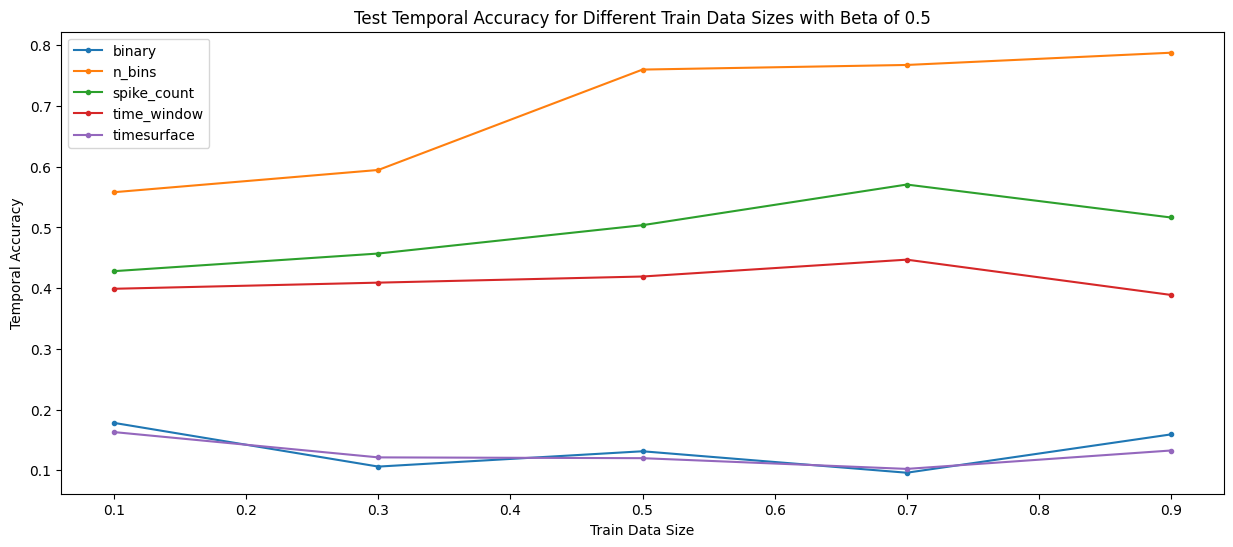

In [7]:
sns.reset_orig()

fig, ax = plt.subplots(figsize=(15, 6))

for representation in grouped_data['representation'].unique():
    rep_data = grouped_data[grouped_data['representation'] == representation]
    plt.plot(rep_data['train_size'], rep_data['test_temp_acc'], label=f'{representation}', marker='.')

plt.xlabel('Train Data Size')
plt.ylabel('Temporal Accuracy')
plt.title('Test Temporal Accuracy for Different Train Data Sizes with Beta of 0.5')
plt.legend()
plt.show()

In [27]:
df = pd.read_csv('../results/dvs128_snn_01_to_09_batch8_3seeds_max_mem_beta09.txt')

In [28]:
df = df.drop(['val_rate_acc', 'val_temp_acc'], axis=1)
df['num_epochs'] = df['num_epochs'] + 1
df.head()

,representation,coding,train_size,val_size,seed,batch_size,test_rate_acc,test_temp_acc,num_epochs,batch_size.1,loss,beta
0,n_bins,max_mem,0.1,0.1,42,8,0.5265,0.5341,18.0,8.0,max_mem,0.9
1,n_bins,max_mem,0.3,0.1,42,8,0.6553,0.6023,24.0,8.0,max_mem,0.9
2,n_bins,max_mem,0.5,0.1,42,8,0.7992,0.7424,22.0,8.0,max_mem,0.9
3,n_bins,max_mem,0.7,0.1,42,8,0.8144,0.7311,20.0,8.0,max_mem,0.9
4,n_bins,max_mem,0.9,0.1,42,8,0.8333,0.7992,20.0,8.0,max_mem,0.9


In [29]:
df = df.drop(['batch_size.1', 'coding', 'beta'], axis=1)
df.head()

,representation,train_size,val_size,seed,batch_size,test_rate_acc,test_temp_acc,num_epochs,loss
0,n_bins,0.1,0.1,42,8,0.5265,0.5341,18.0,max_mem
1,n_bins,0.3,0.1,42,8,0.6553,0.6023,24.0,max_mem
2,n_bins,0.5,0.1,42,8,0.7992,0.7424,22.0,max_mem
3,n_bins,0.7,0.1,42,8,0.8144,0.7311,20.0,max_mem
4,n_bins,0.9,0.1,42,8,0.8333,0.7992,20.0,max_mem


In [30]:
grouped_data = df.groupby(['train_size', 'representation']).agg({
    'test_rate_acc': 'mean',
    'test_temp_acc': 'mean',
    'num_epochs': 'mean'
}).reset_index()
grouped_data = grouped_data.round(2)
grouped_data.head()

,train_size,representation,test_rate_acc,test_temp_acc,num_epochs
0,0.1,binary,0.18,0.18,20.0
1,0.1,n_bins,0.55,0.54,19.0
2,0.1,spike_count,0.47,0.43,20.0
3,0.1,time_window,0.44,0.40,20.0
4,0.1,timesurface,NaN,NaN,NaN


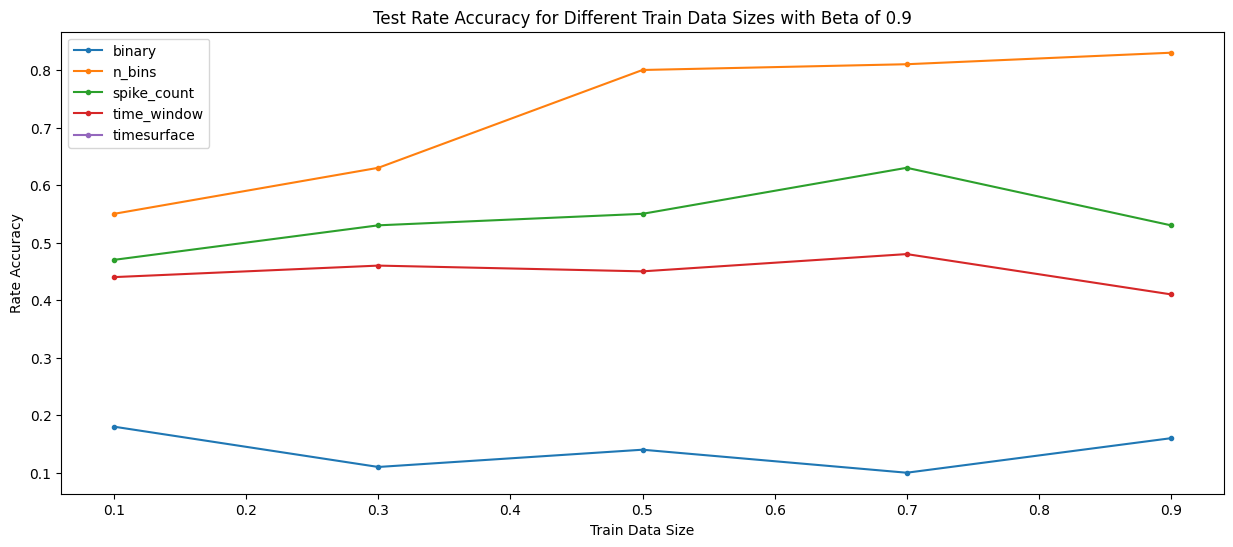

In [31]:
sns.reset_orig()

fig, ax = plt.subplots(figsize=(15, 6))

for representation in grouped_data['representation'].unique():
    rep_data = grouped_data[grouped_data['representation'] == representation]
    plt.plot(rep_data['train_size'], rep_data['test_rate_acc'], label=f'{representation}', marker='.')

plt.xlabel('Train Data Size')
plt.ylabel('Rate Accuracy')
plt.title('Test Rate Accuracy for Different Train Data Sizes with Beta of 0.9')
plt.legend()
plt.show()

In [13]:
df = pd.read_csv('../results/dvs128_snn_09_batch8_max_mem_beta05.txt')
df.head()

,representation,loss,train_size,val_size,random_seed,batch_size,val_rate_acc,val_temp_acc,test_rate_acc,test_temp_acc,num_epochs,batch_size.1,loss.1,beta
0,n_bins,max_mem,0.9,0.1,42,8,0,0,0.8333,0.7992,19.0,8.0,max_mem,0.5
1,binary,max_mem,0.9,0.1,42,8,0,0,0.2045,0.2159,19.0,8.0,max_mem,0.5
2,time_window,max_mem,0.9,0.1,42,8,0,0,0.4318,0.3977,19.0,8.0,max_mem,0.5
3,spike_count,max_mem,0.9,0.1,42,8,0,0,0.5152,0.4962,19.0,8.0,max_mem,0.5
4,timesurface,max_mem,0.9,0.1,42,8,0,0,0.1780,0.1818,19.0,8.0,max_mem,0.5


In [14]:
df = df.drop(['val_rate_acc', 'val_temp_acc'], axis=1)
df['num_epochs'] = df['num_epochs'] + 1
df = df.drop(['batch_size.1', 'loss.1', 'beta'], axis=1)
df.head()

,representation,loss,train_size,val_size,random_seed,batch_size,test_rate_acc,test_temp_acc,num_epochs
0,n_bins,max_mem,0.9,0.1,42,8,0.8333,0.7992,20.0
1,binary,max_mem,0.9,0.1,42,8,0.2045,0.2159,20.0
2,time_window,max_mem,0.9,0.1,42,8,0.4318,0.3977,20.0
3,spike_count,max_mem,0.9,0.1,42,8,0.5152,0.4962,20.0
4,timesurface,max_mem,0.9,0.1,42,8,0.1780,0.1818,20.0


C:\Users\osvat\AppData\Local\Temp\ipykernel_9540\3529193584.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\osvat\AppData\Local\Temp\ipykernel_9540\3529193584.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


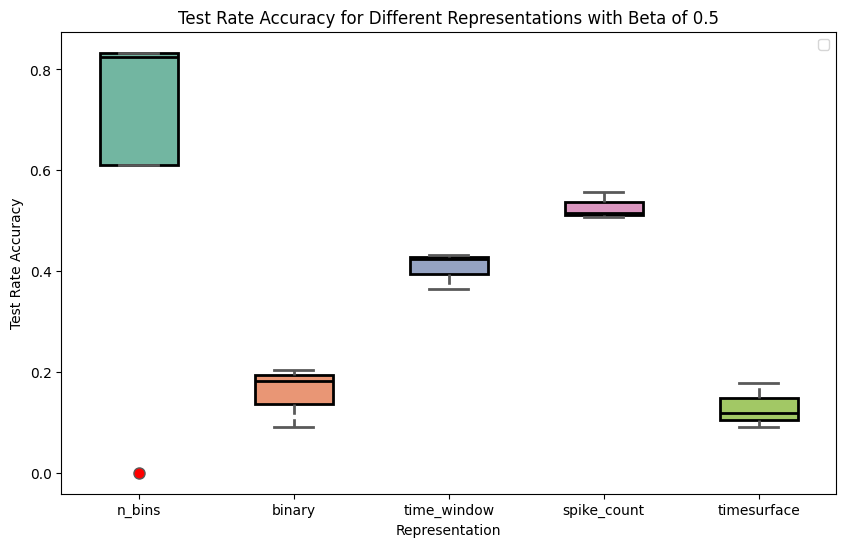

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x="representation", 
    y="test_rate_acc",
    palette="Set2",  # Different colors for each box
    width=0.5,       # Adjust box width
    linewidth=2,     # Border thickness
    flierprops={
        "marker": "o",          # Use points for outliers
        "markerfacecolor": "red",  # Outlier color
        "markersize": 8,        # Outlier size
    },
    whiskerprops={"linestyle": "--"},  # Dashed whiskers
    boxprops={"edgecolor": "black"},  # Box border color
    medianprops={"color": "black"},   # Median line color
)

ax.set_xlabel('Representation')
ax.set_ylabel('Test Rate Accuracy')
ax.set_title('Test Rate Accuracy for Different Representations with Beta of 0.5')
ax.legend()
plt.show()

In [16]:
grouped_data = df.groupby(['representation']).agg({
    'test_rate_acc': ['mean', 'std'],
    'test_temp_acc': ['mean', 'std'],
    'num_epochs': 'mean'
}).reset_index()
grouped_data.head()

representation test_rate_acc           test_temp_acc           num_epochs
                          mean       std          mean       std       mean
0         binary      0.159067  0.060115      0.159100  0.063275       18.0
1         n_bins      0.620250  0.413596      0.590900  0.394042       14.0
2    spike_count      0.526533  0.026486      0.516433  0.023164       18.0
3    time_window      0.406533  0.037375      0.388867  0.015300       18.0
4    timesurface      0.128767  0.044649      0.132567  0.045920       18.0

In [17]:
grouped_data = grouped_data.round(2)
grouped_data.head()

representation test_rate_acc       test_temp_acc       num_epochs
                          mean   std          mean   std       mean
0         binary          0.16  0.06          0.16  0.06       18.0
1         n_bins          0.62  0.41          0.59  0.39       14.0
2    spike_count          0.53  0.03          0.52  0.02       18.0
3    time_window          0.41  0.04          0.39  0.02       18.0
4    timesurface          0.13  0.04          0.13  0.05       18.0

In [18]:
grouped_data.to_csv("dsv_128_snn_maxmem_beta05_grouped.csv")

In [8]:
df = pd.read_csv('../results/dvs128_snn_09_batch8_max_mem_beta09.txt')
df.head()

,representation,loss,train_size,val_size,random_seed,batch_size,val_rate_acc,val_temp_acc,test_rate_acc,test_temp_acc,num_epochs,batch_size.1,loss.1,beta
0,n_bins,max_mem,0.9,0.1,42,8,0,0,0.8333,0.7992,19.0,8.0,max_mem,0.9
1,binary,max_mem,0.9,0.1,42,8,0,0,0.2045,0.2159,19.0,8.0,max_mem,0.9
2,time_window,max_mem,0.9,0.1,42,8,0,0,0.4318,0.3977,19.0,8.0,max_mem,0.9
3,spike_count,max_mem,0.9,0.1,42,8,0,0,0.5152,0.4962,19.0,8.0,max_mem,0.9
4,timesurface,max_mem,0.9,0.1,42,8,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df = df.drop(['val_rate_acc', 'val_temp_acc'], axis=1)
df['num_epochs'] = df['num_epochs'] + 1
df = df.drop(['batch_size.1', 'loss.1', 'beta'], axis=1)
df.head()

,representation,loss,train_size,val_size,random_seed,batch_size,test_rate_acc,test_temp_acc,num_epochs
0,n_bins,max_mem,0.9,0.1,42,8,0.8333,0.7992,20.0
1,binary,max_mem,0.9,0.1,42,8,0.2045,0.2159,20.0
2,time_window,max_mem,0.9,0.1,42,8,0.4318,0.3977,20.0
3,spike_count,max_mem,0.9,0.1,42,8,0.5152,0.4962,20.0
4,timesurface,max_mem,0.9,0.1,42,8,NaN,NaN,NaN


C:\Users\osvat\AppData\Local\Temp\ipykernel_9540\2999479027.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\osvat\AppData\Local\Temp\ipykernel_9540\2999479027.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


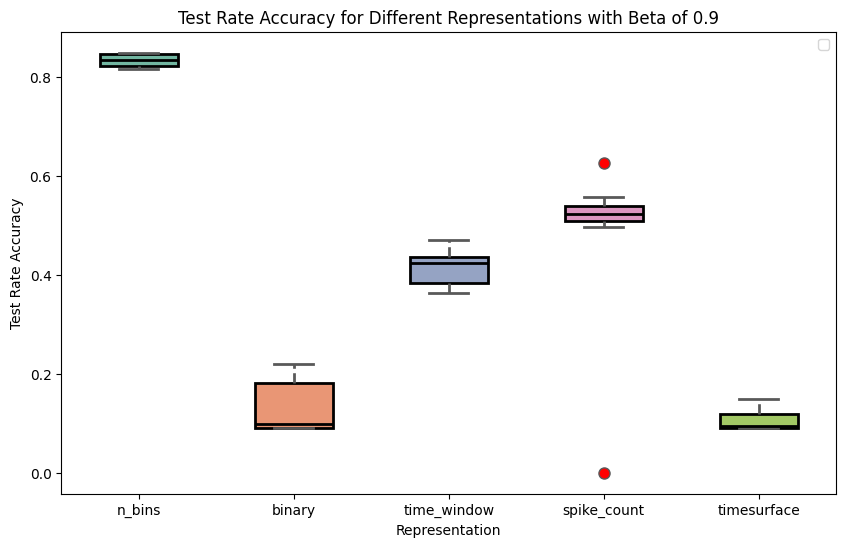

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df, 
    x="representation", 
    y="test_rate_acc",
    palette="Set2",  # Different colors for each box
    width=0.5,       # Adjust box width
    linewidth=2,     # Border thickness
    flierprops={
        "marker": "o",          # Use points for outliers
        "markerfacecolor": "red",  # Outlier color
        "markersize": 8,        # Outlier size
    },
    whiskerprops={"linestyle": "--"},  # Dashed whiskers
    boxprops={"edgecolor": "black"},  # Box border color
    medianprops={"color": "black"},   # Median line color
)

ax.set_xlabel('Representation')
ax.set_ylabel('Test Rate Accuracy')
ax.set_title('Test Rate Accuracy for Different Representations with Beta of 0.9')
ax.legend()
plt.show()

In [11]:
grouped_data = df.groupby(['representation']).agg({
    'test_rate_acc': ['mean', 'std'],
    'test_temp_acc': ['mean', 'std'],
    'num_epochs': 'mean'
}).reset_index()
grouped_data = grouped_data.round(2)
grouped_data.head()

representation test_rate_acc       test_temp_acc       num_epochs
                          mean   std          mean   std       mean
0         binary          0.13  0.05          0.13  0.05      19.78
1         n_bins          0.83  0.01          0.80  0.01      19.78
2    spike_count          0.48  0.18          0.47  0.18      18.00
3    time_window          0.41  0.03          0.41  0.03      19.78
4    timesurface          0.11  0.02          0.11  0.02      20.40

In [12]:
grouped_data.to_csv("dsv_128_snn_maxmem_beta09_grouped.csv")